In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import sys


In [ ]:
df_mnkc = pd.read_csv("/data/rd_exchange/asauvebois/dataset_global/df_micronekton_old.csv", index_col='date', parse_dates= True)


In [ ]:
biomass_selected = "mnkc_epi"
biome_selected = [1.0, 5.0,2.0, 4.0, 3.0]
sliced_biome = [2.0, 3.0, 4.0]



 101.0: p=0.000 | pente=-0.00025 | pente_ref=0.00171 | pourcent=-14.41
 102.0: p=0.000 | pente=-0.00021 | pente_ref=0.00034 | pourcent=-60.65
 103.0: p=0.000 | pente=-0.00025 | pente_ref=0.00155 | pourcent=-16.21
 501.0: p=0.000 | pente=0.00177 | pente_ref=0.00528 | pourcent=33.54
 502.0: p=0.801 | pente=-0.00004 | pente_ref=0.00539 | pourcent=-0.68
 503.0: p=0.744 | pente=-0.00005 | pente_ref=0.00106 | pourcent=-5.20
 201.0: p=0.000 | pente=-0.00105 | pente_ref=-0.00122 | pourcent=86.59
 202.0: p=0.166 | pente=-0.00020 | pente_ref=0.00482 | pourcent=-4.10
 203.0: p=0.000 | pente=-0.00041 | pente_ref=-0.00188 | pourcent=21.74
 204.0: p=0.268 | pente=-0.00024 | pente_ref=0.00772 | pourcent=-3.08
 205.0: p=0.024 | pente=-0.00035 | pente_ref=-0.00148 | pourcent=23.42
 401.0: p=0.071 | pente=-0.00043 | pente_ref=0.00258 | pourcent=-16.58
 402.0: p=0.713 | pente=0.00011 | pente_ref=0.01239 | pourcent=0.91
 403.0: p=0.000 | pente=-0.00059 | pente_ref=-0.00425 | pourcent=13.77
 404.0: p=0.087

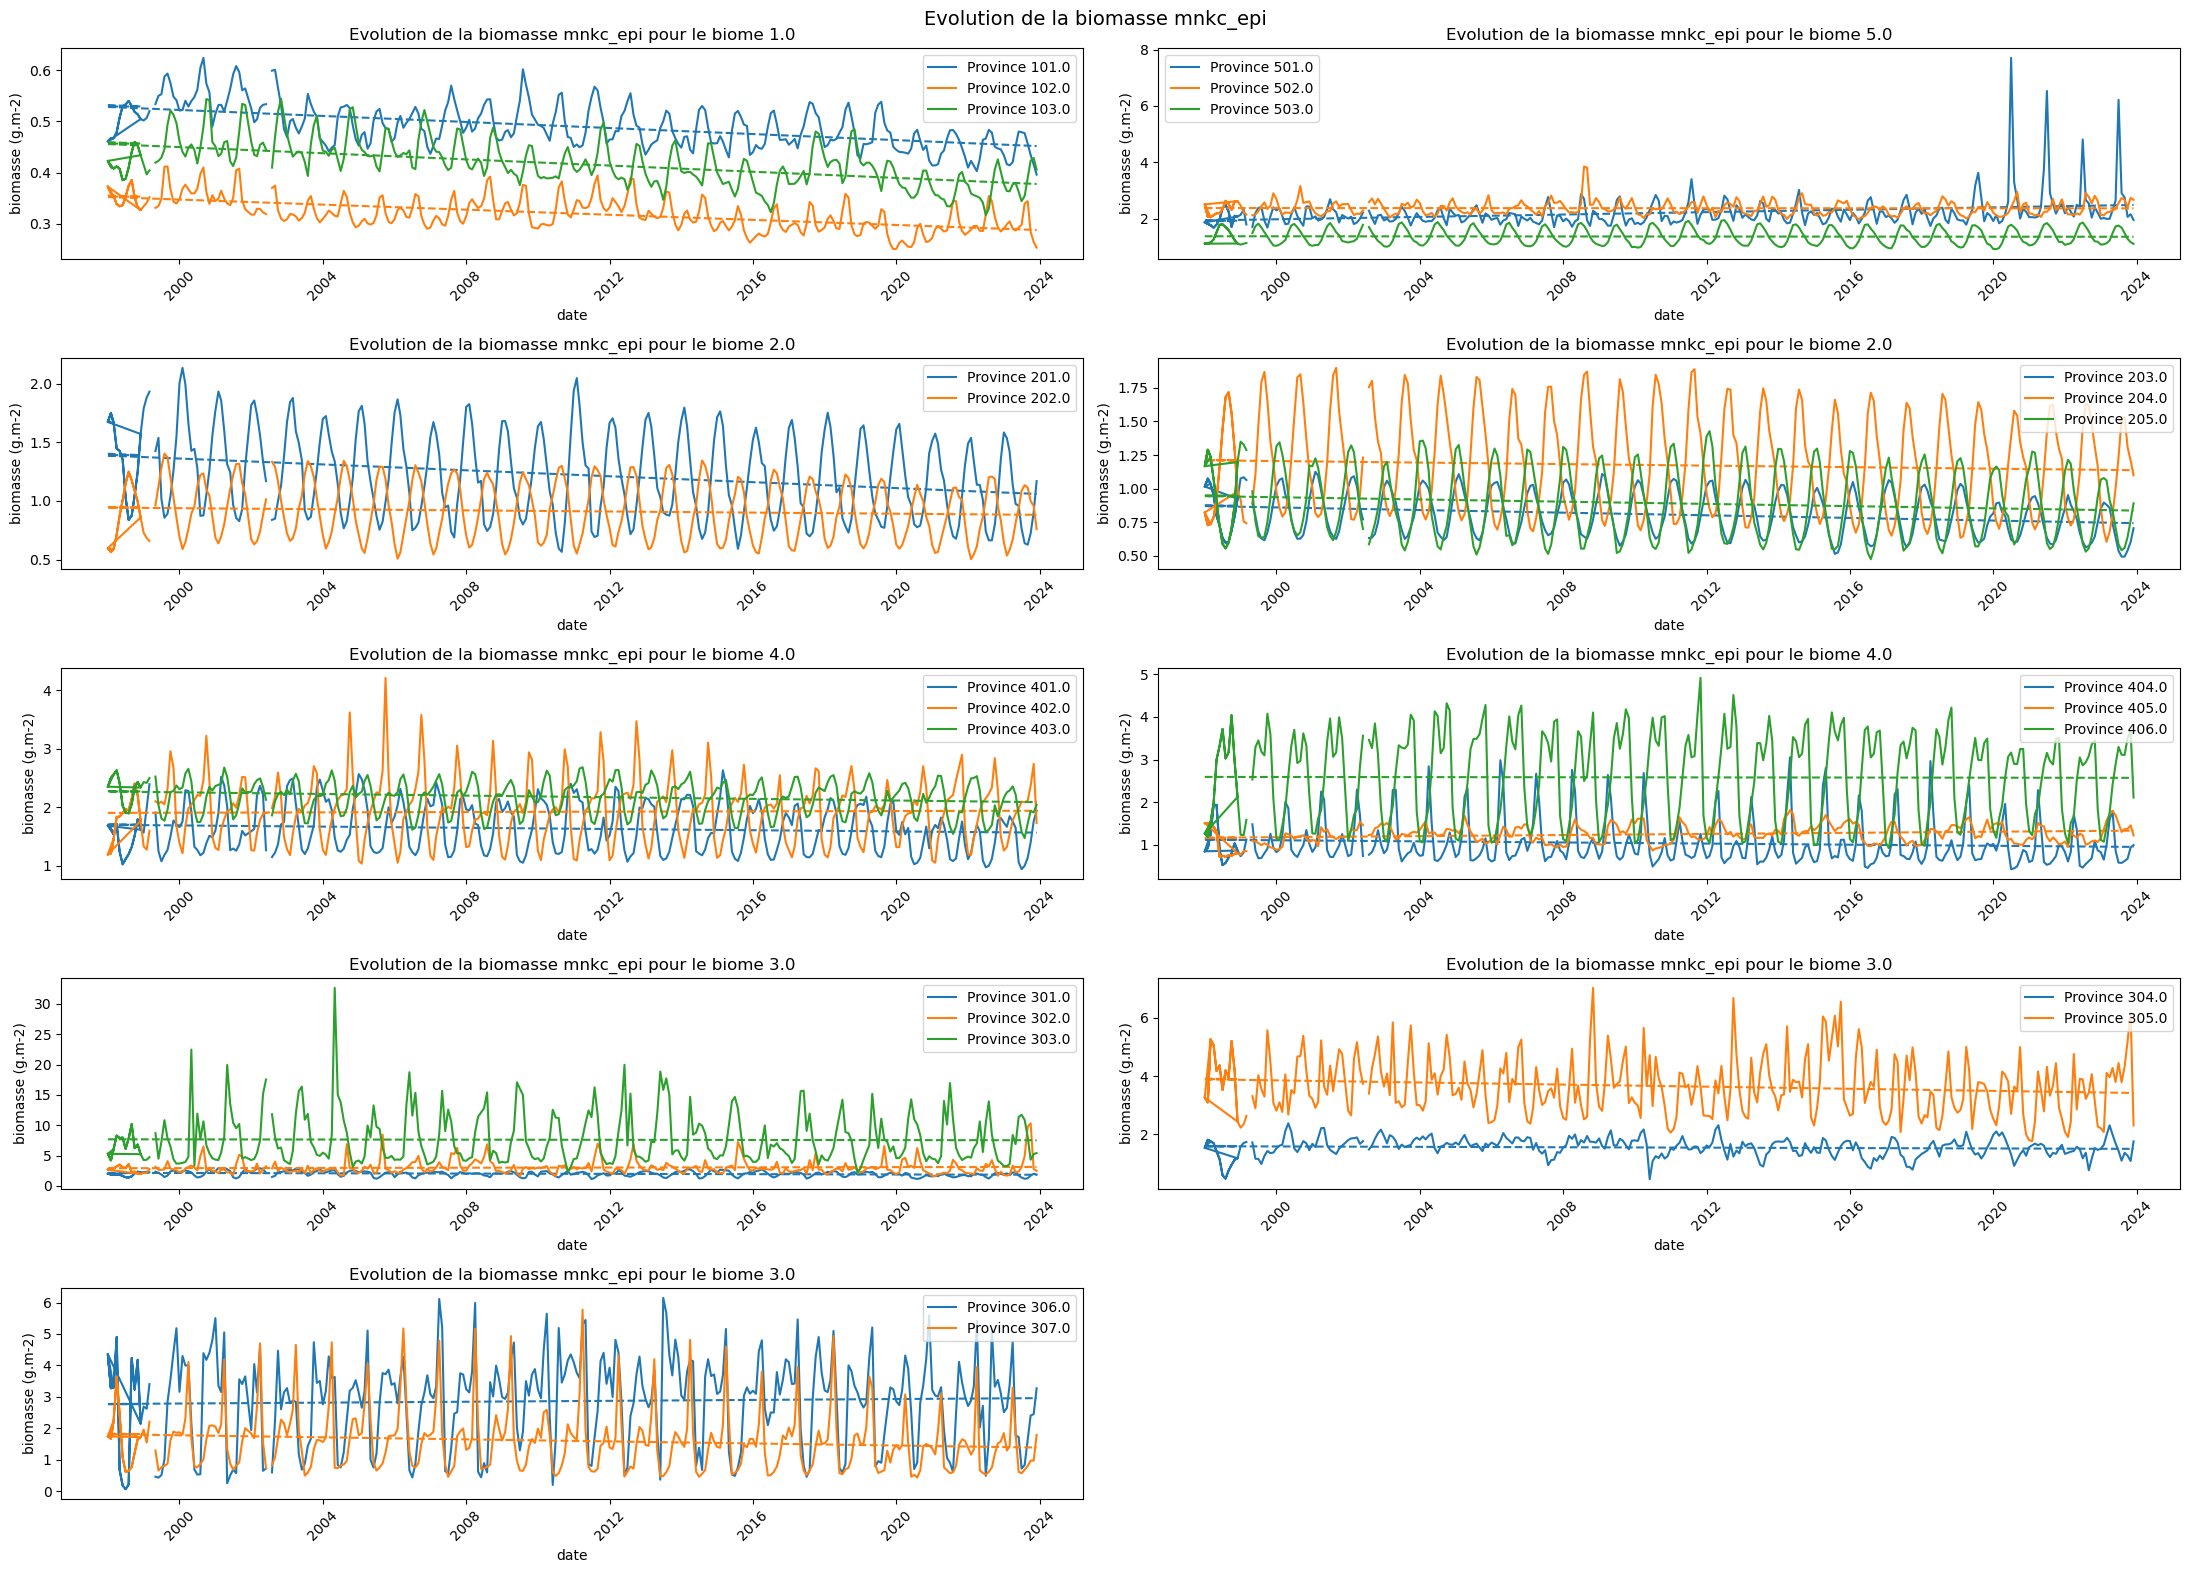

In [20]:
plt.figure(figsize=(22, 16))

subplot_idx = 1


for biome in biome_selected:
    df_by_biome= df_mnkc[df_mnkc["Biome"] == biome]
    provinces= list(df_by_biome["prov"].unique())

    if len(provinces) <=3:
        groups = [provinces]
    elif len(provinces) <= 6:
        middle = len(provinces) // 2
        groups = [provinces[:middle], provinces[middle:]]
    else:  # 7 provinces → 3 groupes de 3, 2, 2
        groups = [provinces[:3], provinces[3:5], provinces[5:]]
    

    for group in groups:
        plt.subplot(5, 2, subplot_idx)

        for prov_id in group:
            df_prov= df_by_biome[df_by_biome['prov'] == prov_id]
            df_prov_ref = df_prov[df_prov.index.year <= df_prov.index.year[0] + 2]
        

            y = df_prov[biomass_selected].values
            x = np.arange(len(y))
           
            y_ref = df_prov_ref[biomass_selected].values
            x_ref = np.arange(len(y_ref))
      
            # Supprimer les NaN
            mask_valid = ~np.isnan(y)
            x_clean = x[mask_valid]
            y_clean = y[mask_valid]

            mask_valid_ref = ~np.isnan(y_ref)
            x_ref_clean = x_ref[mask_valid_ref]
            y_ref_clean = y_ref[mask_valid_ref]
           
            
            # Régression
            slope, intercept, r, pvalue, se = stats.linregress(x_clean, y_clean)
            slope_ref = stats.linregress(x_ref_clean, y_ref_clean).slope

            percent_slope= 100*slope/slope_ref
            
            # Courbe donnée
            plt.plot(df_prov.index, y, label=f"Province {prov_id}")
            color = plt.gca().lines[-1].get_color() if plt.gca().lines else None
            
            # Droite de régression (même couleur)
            plt.plot(df_prov.index[mask_valid], intercept + slope * x_clean,
                     linestyle='--', color=color)
            print(f" {prov_id}: p={pvalue:.3f} | pente={slope:.5f} | pente_ref={slope_ref:.5f} | pourcent={percent_slope:.2f}")


            
        plt.title(f"Evolution de la biomasse {biomass_selected} pour le biome {biome}")
        plt.xlabel("date")
        plt.ylabel("biomasse (g.m-2)")
        plt.legend()
        plt.xticks(rotation=45)

        subplot_idx +=1

plt.suptitle(f"Evolution de la biomasse {biomass_selected}", fontsize=14)
plt.tight_layout()
plt.show()

